<h2>Customer Sales Prediction & Spending Analysis</h2>

<h4>Project Goal</h4>

<h4>Step 1-: Import Libraries</h4>

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression,LogisticRegression

<h4>Step 2-:Load Dataset</h4>

In [54]:
data = pd.read_csv("Advertising.csv")

In [55]:
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [56]:
data.shape

(200, 5)

In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [58]:
data.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [59]:
data.isnull().sum()[data.isnull().sum()>0]

Series([], dtype: int64)

<h4>Step 3-:Exploratory Data Analysis(Visualization)</h4>

<h4>Histogram</h4>

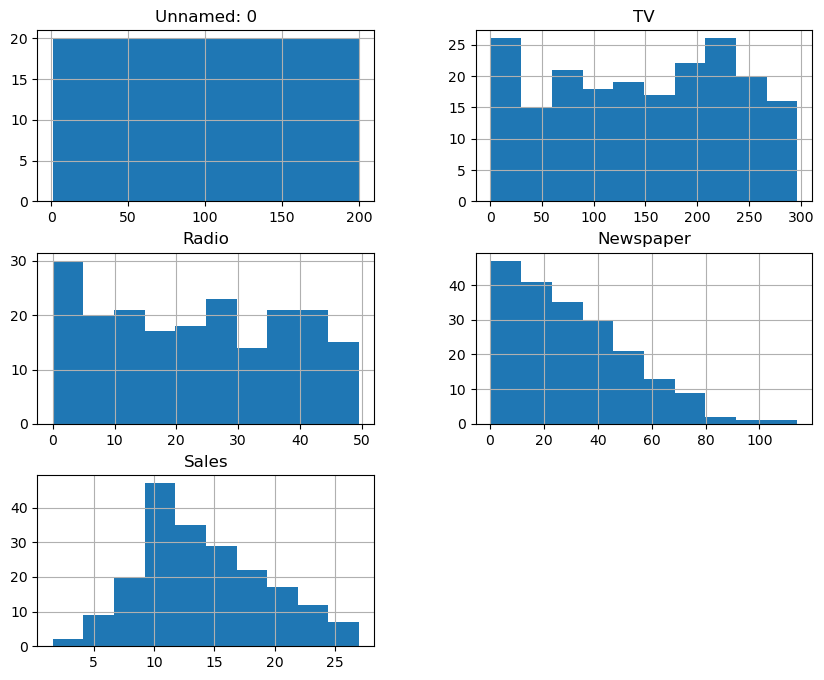

In [60]:
data.hist(figsize=(10,8))
plt.show()

<h4>Correlation Heatmap</h4>

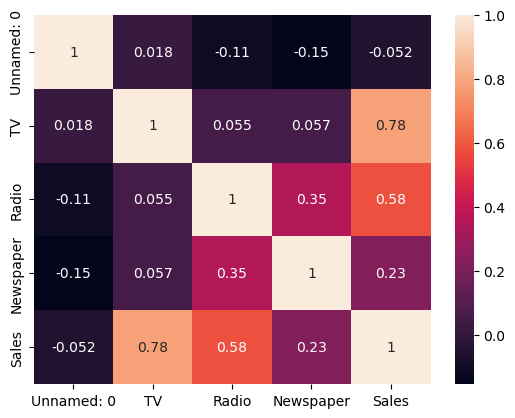

In [61]:
sns.heatmap(data.corr(), annot=True)
plt.show()

<h4>Pairplot</h4>

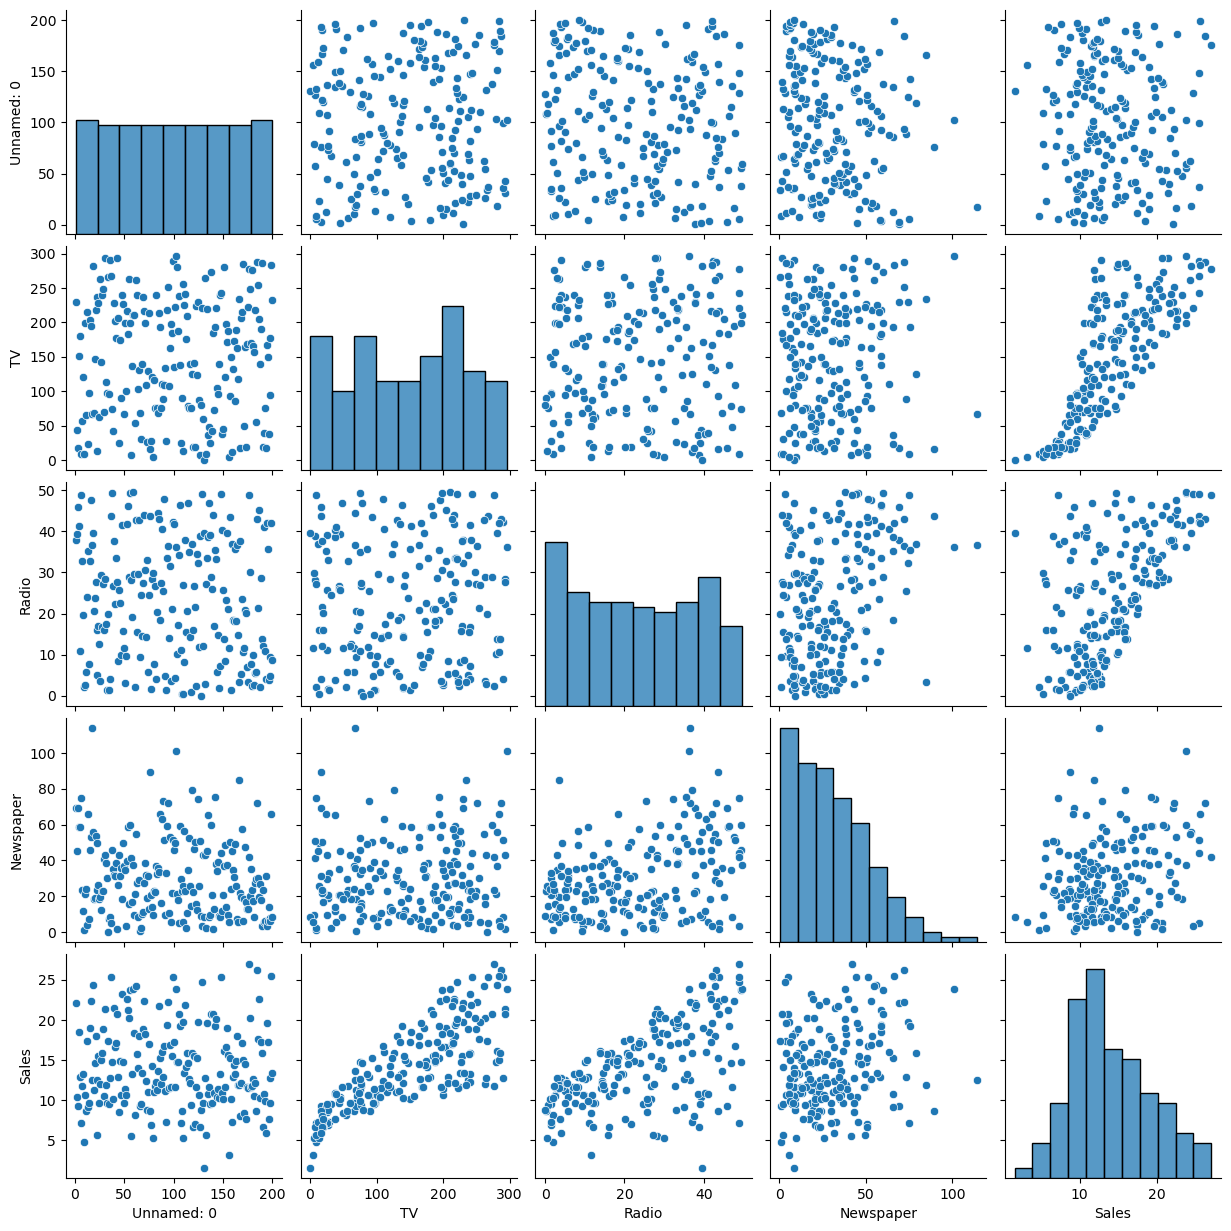

In [62]:
sns.pairplot(data)
plt.show()

<h4>Step 4-:Linear Regression (Predict Sales)</h4>

In [63]:
x = data[['TV','Radio','Newspaper']]
y = data['Sales']

In [64]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [66]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [67]:
with open(r'C:\Users\manoh\OneDrive\Desktop\Sales Deploy\linear_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

print("Model saved successfully")

Model saved successfully


In [68]:
y_pred = lr.predict(x_test)

<h4>Step 5-:Evaluation</h4>

In [69]:
from sklearn.metrics import r2_score, mean_squared_error
print(r2_score(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

0.899438024100912
1.7815996615334502


In [70]:
data['Purchased'] = np.where(data['Sales']> 10,1,0)
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales,Purchased
0,1,230.1,37.8,69.2,22.1,1
1,2,44.5,39.3,45.1,10.4,1
2,3,17.2,45.9,69.3,9.3,0
3,4,151.5,41.3,58.5,18.5,1
4,5,180.8,10.8,58.4,12.9,1


<h4>Step 6-:Logistic Regression (Predict Purchased)</h4>

In [71]:
x = data[['TV','Radio','Newspaper']]
y = data['Purchased']

In [72]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [74]:
logr = LogisticRegression()
logr.fit(x_train, y_train)

LogisticRegression()

In [75]:
y_pred = logr.predict(x_test)

<h4>Step 7-:Evaluation</h4>

In [76]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

1.0
[[11  0]
 [ 0 29]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        29

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



<h4>Step 8-:Visualize Classification Result</h4>

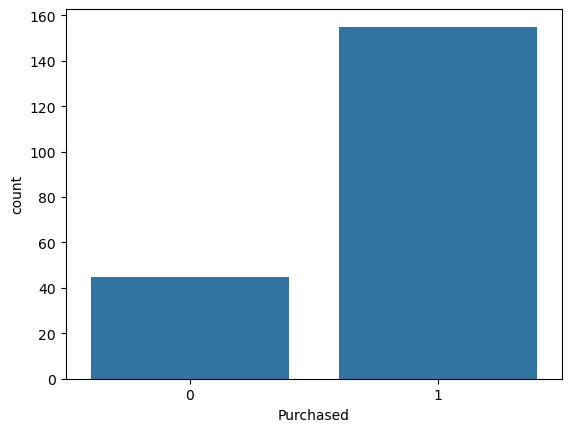

In [77]:
sns.countplot(x='Purchased',data=data)
plt.show()

In [78]:
import pickle

# Save Linear Regression
pickle.dump(lr, open('linear_model.pkl', 'wb'))

# Save Logistic Regression
pickle.dump(logr, open('logistic_model.pkl', 'wb'))

# Save scaler
pickle.dump(scaler, open('scaler.pkl', 'wb'))